In [1]:
import os 
import pickle 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



In [4]:
parent_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/halfmap_improvement_study"
list_of_emdb = [x.split("_")[1] for x in os.listdir(parent_folder) if x.startswith("emd_")]
all_pickle_files = [os.path.join(parent_folder, f"emd_{emd}", f"fsc_data_emdb_{emd}.pkl") for emd in list_of_emdb]
all_fsc_data = {}
for emd, pkl_file in zip(list_of_emdb, all_pickle_files):
    with open(pkl_file, "rb") as f:
        all_fsc_data[emd] = pickle.load(f)


In [5]:
all_fsc_data["0282"].keys()
fsc_curves_baselines = {} 
fsc_curves_halfmaps = {}
fsc_curves_fems = {}
improvement_in_fsc = {}
for emdb in list_of_emdb:
    fsc_data_emdb = all_fsc_data[emdb]
    baseline_1_fsc = fsc_data_emdb["fsc_curve_baseline_1"]
    baseline_2_fsc = fsc_data_emdb["fsc_curve_baseline_2"]
    control_fsc = fsc_data_emdb["fsc_curve_control"]
    fem_1_fsc = fsc_data_emdb["fsc_curve_1"]
    fem_2_fsc = fsc_data_emdb["fsc_curve_2"]
    freq_array = fsc_data_emdb["freq_array_1"]
    assert np.allclose(freq_array, fsc_data_emdb["freq_array_2"]), "Frequency arrays do not match between half-maps and FEMs for EMDB {}".format(emdb)
    baseline_fsc = np.mean([baseline_1_fsc, baseline_2_fsc], axis=0)
    fem_fsc = np.mean([fem_1_fsc, fem_2_fsc], axis=0)

    fsc_curves_baselines[emdb] = (freq_array, baseline_fsc)
    fsc_curves_halfmaps[emdb] = (freq_array, control_fsc)
    fsc_curves_fems[emdb] = (freq_array, fem_fsc)
    index_of_freq_10A = np.argmin(np.abs(freq_array - 0.2))
    fsc_baseline_high_res = baseline_fsc[index_of_freq_10A:]
    fsc_fem_high_res = fem_fsc[index_of_freq_10A:]
    fsc_average_baseline_high_res = np.mean(fsc_baseline_high_res)
    fsc_average_fem_high_res = np.mean(fsc_fem_high_res)
    improvement = fsc_average_fem_high_res - fsc_average_baseline_high_res
    improvement_in_fsc[emdb] = improvement




In [6]:
improvement_in_fsc

{'0282': 0.02600652227614564,
 '0311': 0.0052742816557160704,
 '0560': -0.012207102563873973,
 '10365': 0.010375233120829441,
 '20220': 0.018978604700513768,
 '20226': -0.047312243694502376,
 '3545': 0.00225484611464067,
 '4141': -0.0036490454990485734,
 '4531': -0.01978148798789786,
 '4571': 0.03576805533773664,
 '4997': 0.012239157136300027,
 '7127': 0.02419466131272527,
 '8702': -0.0024987834739455816,
 '9610': 0.025163753579415693}

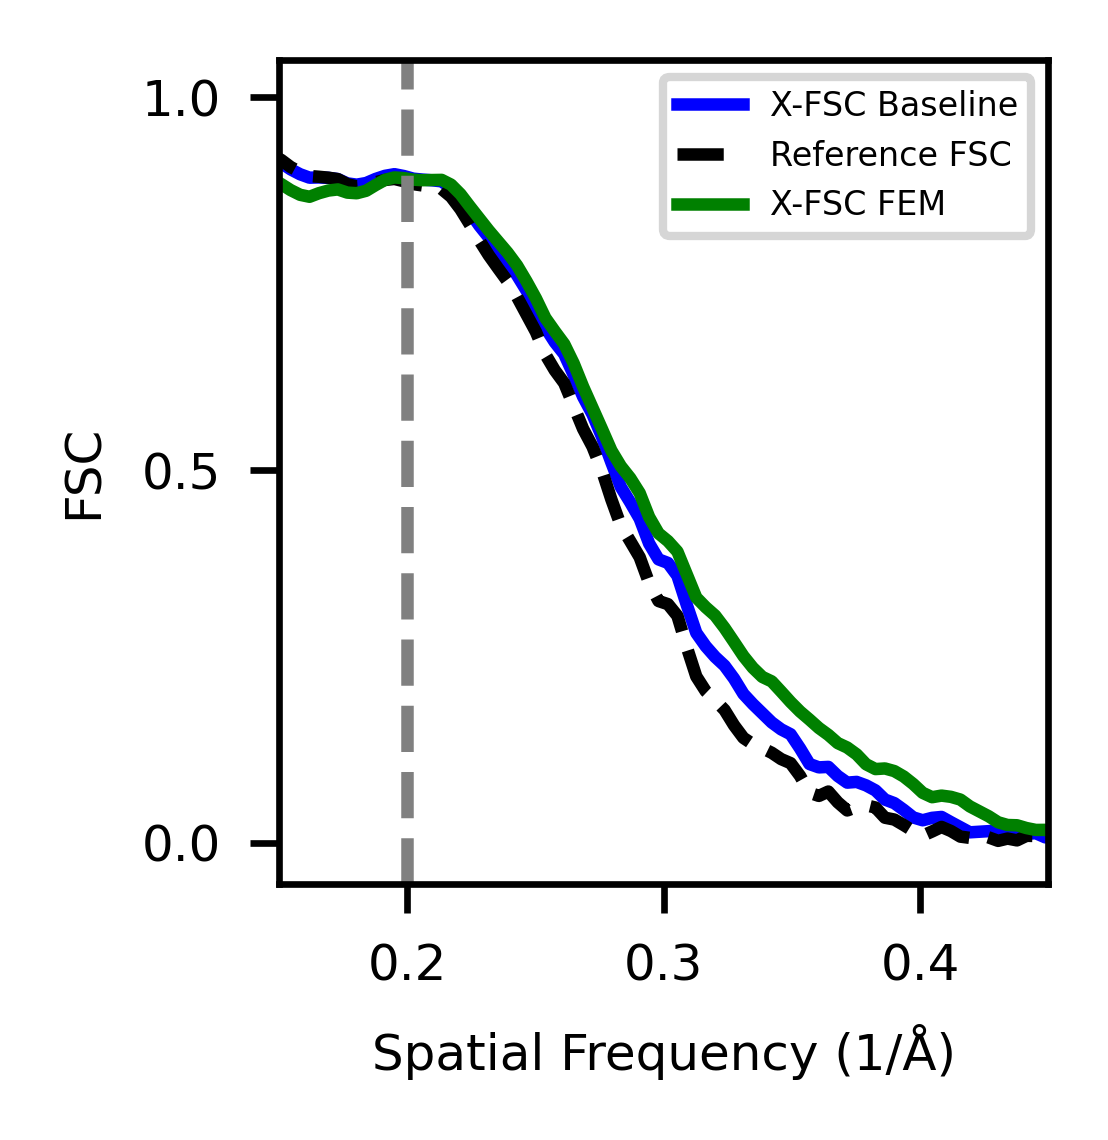

In [16]:
# improt rcParams to set font globally for all plots
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueType fonts
emdb_to_check = "0282"
freq_baseline, fsc_baseline = fsc_curves_baselines[emdb_to_check]
freq_halfmap, fsc_halfmap = fsc_curves_halfmaps[emdb_to_check]
freq_fem, fsc_fem = fsc_curves_fems[emdb_to_check]

# dump the fsc curve data to csv for the emdb of interest
import pandas as pd 
fsc_data = []
headers = ["frequency", "fsc_value", "curve_type"]
for freq, fsc_b, fsc_h, fsc_f in zip(freq_baseline, fsc_baseline, fsc_halfmap, fsc_fem):
    fsc_data.append([freq, fsc_b, "xfsc_baseline"])
    fsc_data.append([freq, fsc_h, "fsc_reference"])
    fsc_data.append([freq, fsc_f, "xfsc_fem"])

fsc_data_df = pd.DataFrame(fsc_data, columns=headers)

output_dir = "/home/abharadwaj1/thesis/publications/notebooks/LocScale2.0_NComms_2026_plotData"
save_path = os.path.join(output_dir, f"s7_cross_FSC_0282.csv")
fsc_data_df.to_csv(save_path, index=False)

plt.figure(figsize=(2, 2), dpi=600)
plt.plot(freq_baseline, fsc_baseline, label="X-FSC Baseline", color="blue")
plt.plot(freq_halfmap, fsc_halfmap, label="Reference FSC", color="black", linestyle="--")
plt.plot(freq_fem, fsc_fem, label="X-FSC FEM", color="green")
plt.xlabel("Spatial Frequency (1/Å)", fontsize=6)
plt.ylabel("FSC", fontsize=6)
y1 = 0.5
y2 = 0.143
x1 = 0.2
plt.axvline(x=x1, color='gray', linestyle='--')
#plt.axhline(y=y1, color='red', linestyle='--')
#plt.axhline(y=y2, color='orange', linestyle='--')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.xlim(0.15, 0.45)
plt.xticks([0.2, 0.3, 0.4])
plt.legend(fontsize=4, loc="upper right")
save_path_1 = f"/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/halfmap_improvement_study/emd_{emdb_to_check}/fsc_comparison_emdb_{emdb_to_check}.pdf"
plt.tight_layout()
#plt.savefig(save_path_1)

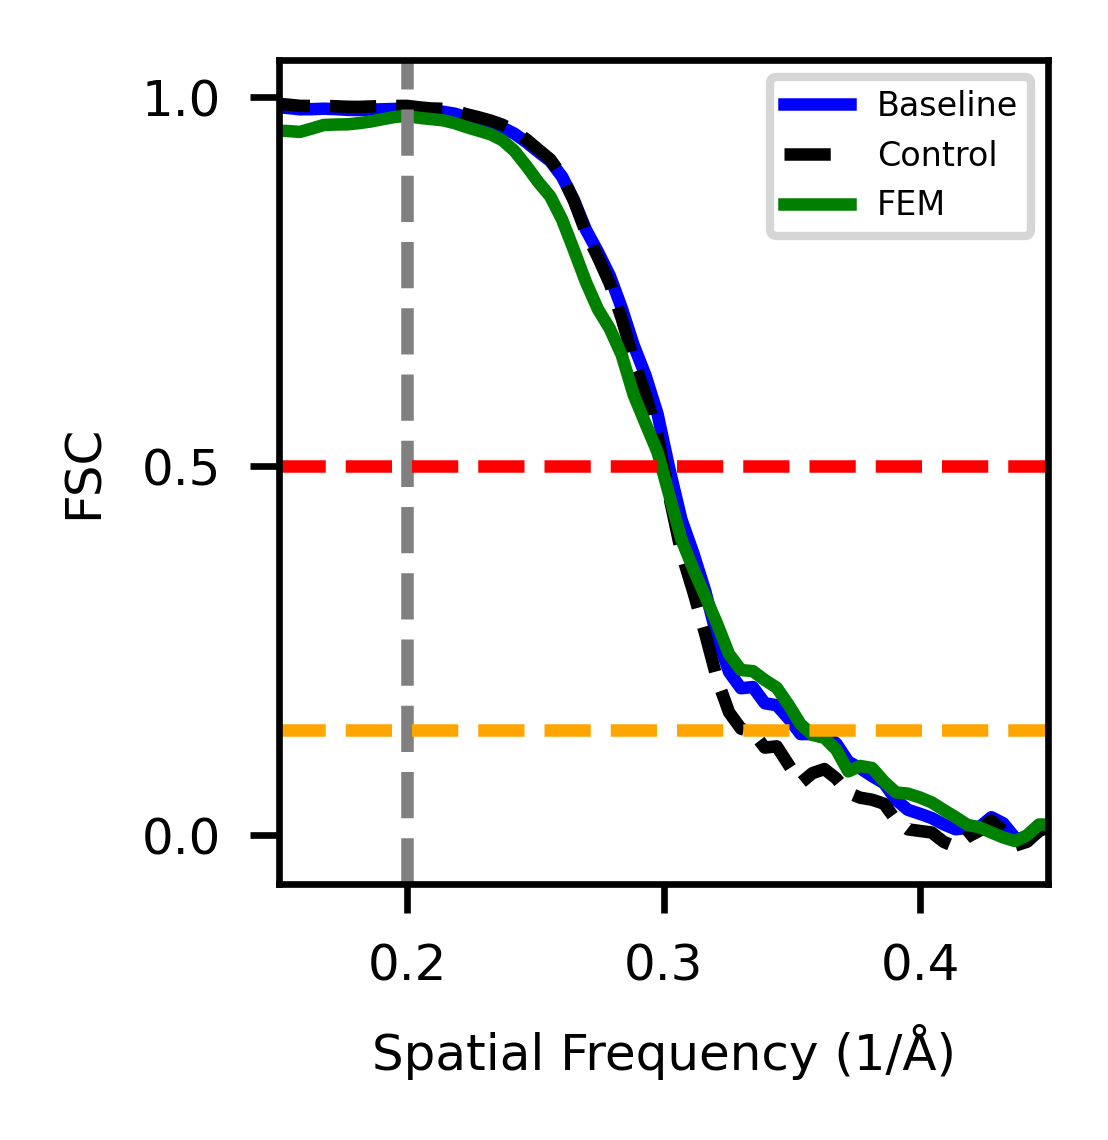

In [21]:
# improt rcParams to set font globally for all plots
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueType fonts
emdb_to_check = "0560"
freq_baseline, fsc_baseline = fsc_curves_baselines[emdb_to_check]
freq_halfmap, fsc_halfmap = fsc_curves_halfmaps[emdb_to_check]
freq_fem, fsc_fem = fsc_curves_fems[emdb_to_check]

plt.figure(figsize=(2, 2), dpi=600)
plt.plot(freq_baseline, fsc_baseline, label="Baseline", color="blue")
plt.plot(freq_halfmap, fsc_halfmap, label="Control", color="black", linestyle="--")
plt.plot(freq_fem, fsc_fem, label="FEM", color="green")
plt.xlabel("Spatial Frequency (1/Å)", fontsize=6)
plt.ylabel("FSC", fontsize=6)
y1 = 0.5
y2 = 0.143
x1 = 0.2
plt.axvline(x=x1, color='gray', linestyle='--')
plt.axhline(y=y1, color='red', linestyle='--')
plt.axhline(y=y2, color='orange', linestyle='--')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.xlim(0.15, 0.45)
plt.xticks([0.2, 0.3, 0.4])
plt.legend(fontsize=4, loc="upper right")
save_path_1 = f"/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/halfmap_improvement_study/emd_{emdb_to_check}/fsc_comparison_emd_{emdb_to_check}_zoom.pdf"
plt.tight_layout()
#plt.savefig(save_path_1)

/tmp/ipykernel_3180/1711147943.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_emdb_ids, y=sorted_improvements, palette="viridis")


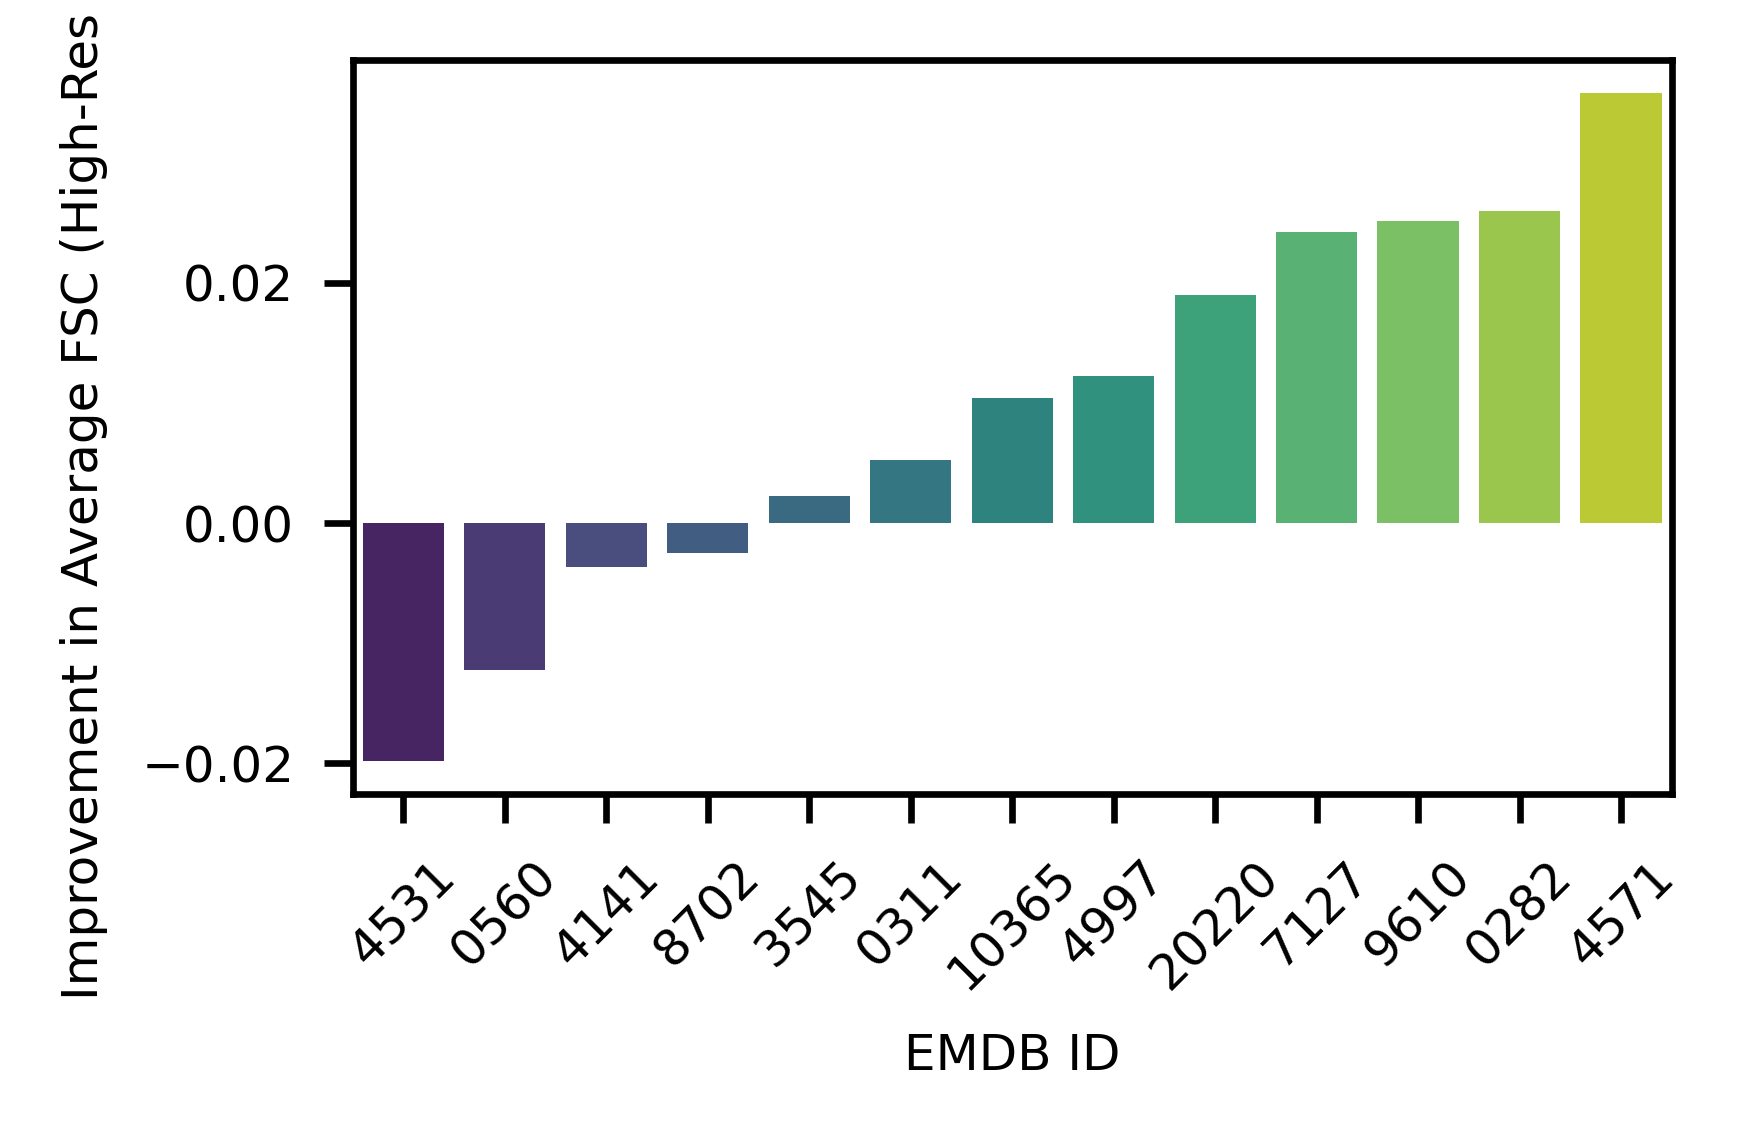

In [19]:
# Plotting the FSC improvement 
plt.figure(figsize=(3,2), dpi=600)
emdb_ids = list(improvement_in_fsc.keys())
emdb_ids_to_plot = [f"{emdb}" for emdb in emdb_ids if emdb != "20226"]
improvements = [improvement_in_fsc[emdb] for emdb in emdb_ids_to_plot]
# sort based on improvements
sorted_indices = np.argsort(improvements)
sorted_emdb_ids = [emdb_ids_to_plot[i] for i in sorted_indices]
sorted_improvements = [improvements[i] for i in sorted_indices]
# dump the sorted emdb data to csv 
improvement_data = []
for emdb, improvement in zip(sorted_emdb_ids, sorted_improvements):
    improvement_data.append([emdb, improvement])
improvement_df = pd.DataFrame(improvement_data, columns=["EMDB_ID", "FSC_Improvement"])
output_dir = "/home/abharadwaj1/thesis/publications/notebooks/LocScale2.0_NComms_2026_plotData"
save_path = os.path.join(output_dir, f"s7_H_improvement_emdb.csv")
improvement_df.to_csv(save_path, index=False)

sns.barplot(x=sorted_emdb_ids, y=sorted_improvements, palette="viridis")
plt.xlabel("EMDB ID", fontsize=6)
plt.ylabel("Improvement in Average FSC (High-Res < 5A)", fontsize=6)
plt.xticks(rotation=45, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
save_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/halfmap_improvement_study/fsc_improvement_barplot.pdf"
#plt.savefig(save_path, dpi=600)

In [20]:
sorted_emdb_ids

['4531',
 '0560',
 '4141',
 '8702',
 '3545',
 '0311',
 '10365',
 '4997',
 '20220',
 '7127',
 '9610',
 '0282',
 '4571']

from locscale.include.emmer.ndimage.map_utils import measure_mask_parameters

#mask_path_19999 = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/sub_tomogram_analysis/new_sta_maps/emd_19999/emd_19999_unsharpened_confidenceMap.mrc"
mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/transmembrane/emd_51108/processing_files/EMD_51108_unsharpened_fullmap_confidenceMap.mrc"

measure_mask_parameters(mask_path)

In [65]:
sorted_indices

array([ 7,  2,  6, 11,  5,  1,  3,  9,  4, 10, 12,  0,  8])

In [17]:
1/0.2

5.0